### Methodology — Revenue Projection

#### Step 1 — Benchmark Selection
I evaluated three approved ADCs that launched into solid tumor
indications with no prior approved ADC as potential commercial
analogues for NEOK001 in PDAC _(see 3_indication_scoring.ipynb for PDAC selection process)_:

| Benchmark | Indication | Payload | Companion Dx | Line | Ph3 at launch |
|-----------|-----------|---------|-------------|------|--------------|
| Trodelvy | TNBC | Topo-I (SN-38) | No | 2L+ | No |
| Padcev | Urothelial | MMAE | No | 2L+ | Yes |
| Elahere | Pt-resistant Ovarian | DM4 | Yes (FRα) | 3L+ | No |

After looking at their US launch trajectories:
- Padcev grew fastest - it had Phase 3 data at approval, which NEOK001 may not have at initial launch
- Elahere grew slowest — required FRα companion dx and also launched at 3L+, making it also a less direct analogue for NEOK001 in PDAC
- Trodelvy would most closely match NEOK001's expected launch conditions

<br>

---

#### Step 2 — Selecting Trodelvy as Primary Anchor
Trodelvy most closely matches NEOK001's expected launch situation:
- Same payload class (Topo-I inhibitor; SN-38 vs exatecan)
- First ADC in indication, no prior ADC competitor at launch
- No companion diagnostic required
- 2L+ positioning — same as NEOK001 in PDAC
- Extending towards 1L now for specific mTNBC patients, now in early 2026, based on Ph3 data
- 4 full years of US sales data available (2020–2024)

> - NEOK001 is unlikely to have Phase 3 data at initial launch (currently Phase 1) — ruling out Padcev as primary anchor
> - Elahere's companion dx requirement and 3L+ positioning make it a less direct analogue for NEOK001 in PDAC

<br>

---

#### Step 3 — Scaling to NEOK001 PDAC Pool
Trodelvy's annual US revenues will be scaled to the NEOK001 PDAC addressable pool using revenue per addressable patient, with a price adjustment for WAC difference:
```
Trodelvy revenue per addressable patient (trodelvy_sales):
= Trodelvy US sales / TNBC addressable pool [19,475 pts]

NEOK001 projected revenue per addressable patient:
= trodelvy_sales × (PDAC SAM 15,842 pts ÷ TNBC pool 19,475 pts) × WAC adjustment ($200K ÷ $364K = 0.549)
```

<br>

**Addressable pools from Report 3 (3_indication_scoring.ipynb):**
- TNBC pool:  48,687 incidence × 40% eligible = 19,475 pts/yr
- PDAC SAM:   67,530 × 51% × 50% × 92%       = 15,842 pts/yr

**WAC values estimated from Report 4 (4_Market_Research.md)**
- Trodelvy annual WAC = 364,000
  - Gilead price info page Jan 1 2026: $20,918/cycle × 17.4 cycles
- NEOK001 assumed annual WAC = 200,000

> Year 0 in the projection corresponds to a partial-year launch equivalent to Trodelvy's April 2020 approval (~8 months of sales). Year 1 onward reflects full annual sales.

<br>

---

#### Step 4 — Upper and Lower Bounds
A ±25% buffer is applied around the Trodelvy-scaled base case to reflect PDAC-specific uncertainties not captured by direct pool/price scaling. The buffer is judgment-based rather than derived from a separate quantitative model.

**Lower bound (75% of base):**
- Phase 1/2 data only at launch → slower physician adoption
  than Trodelvy (which had clear accelerated approval pathway)
- Real-world drop-off from biomarker testing rates, access friction, and reimbursement delays — applies regardless of whether a formal CDx is required

**Upper bound (125% of base):**
- First-in-class in PDAC with no ADC competitor at launch
- Strong Phase 1/2 data could accelerate adoption
- Potential earlier line expansion if data supports (following Trodelvy)
- Bispecific selectivity (ROR1 × B7-H3) may broaden eligible population vs single-target ADCs

> CDx is not used as a quantitative scaling factor in the bounds. NEOK001's CDx requirement is unknown until Phase 1/2 readout, so its impact is treated as one of several adoption-pace uncertainties absorbed into the ±25% range. See `4_Market_Research.md` Limitation #2.

> Note on shorter PDAC survival (mOS 4.2 months vs TNBC 6.7 months): this affects per-patient treatment duration uniformly across all three scenarios, so it is not used as a differential bound factor. The base case implicitly inherits PDAC survival by anchoring to PDAC SAM patient counts; if anything, the Trodelvy-scaled base case slightly overstates per-patient revenue because TNBC patients receive more cycles on average.

---

---

### Limitations
1. Scaling assumes similar physician adoption dynamics between TNBC and PDAC. PDAC is a harder indication to develop in (poor performance status at diagnosis, rapid progression, fewer eligible patients reach later lines) so adoption may be slower than the Trodelvy analog suggests.
2. WAC assumption (NEOK001's $200K) is an estimate; actual pricing at launch is unknown
3. ROR1 92% detection is from CPTAC proteomics (mass spec). Actual IHC positivity with the NEOK001 antibody is unknown — PDAC was not on ABL Bio's publicly disclosed TMA IHC slide. Mass-spec detection is more sensitive than diagnostic IHC, so the 92% likely represents an upper bound on clinically eligible patients.
4. Projections to Year 4 only to match available Trodelvy data; peak may occur later with label expansion
5. The ±25% buffer is a judgment-based range, not a confidence interval — actual outcomes may fall outside this range


In [1]:
# NEOK Bio brand color palette — will be used consistently across all figures
NEOK_DARK =  '#0D4A47'  # darkest teal 
NEOK_MID =   '#0D7A6E'  # mid teal
NEOK_TEAL =  '#0D9488'  # standard teal 
NEOK_LIGHT = '#BBF7D0'  # lightest 

=== NEOK001 PROJECTED TRAJECTORIES ===

Trodelvy pool: 19,475 pts | PDAC SAM: 15,842 pts | Price adj: 0.549

Year     Trodelvy   Conservative    Base Case   Optimistic
----------------------------------------------------------
Yr 0   $      49M $        16.4M $      21.9M $      27.4M
Yr 1   $     370M $       124.1M $     165.4M $     206.8M
Yr 2   $     525M $       175.9M $     234.6M $     293.2M
Yr 3   $     777M $       260.5M $     347.3M $     434.1M
Yr 4   $     877M $       294.0M $     392.0M $     490.0M


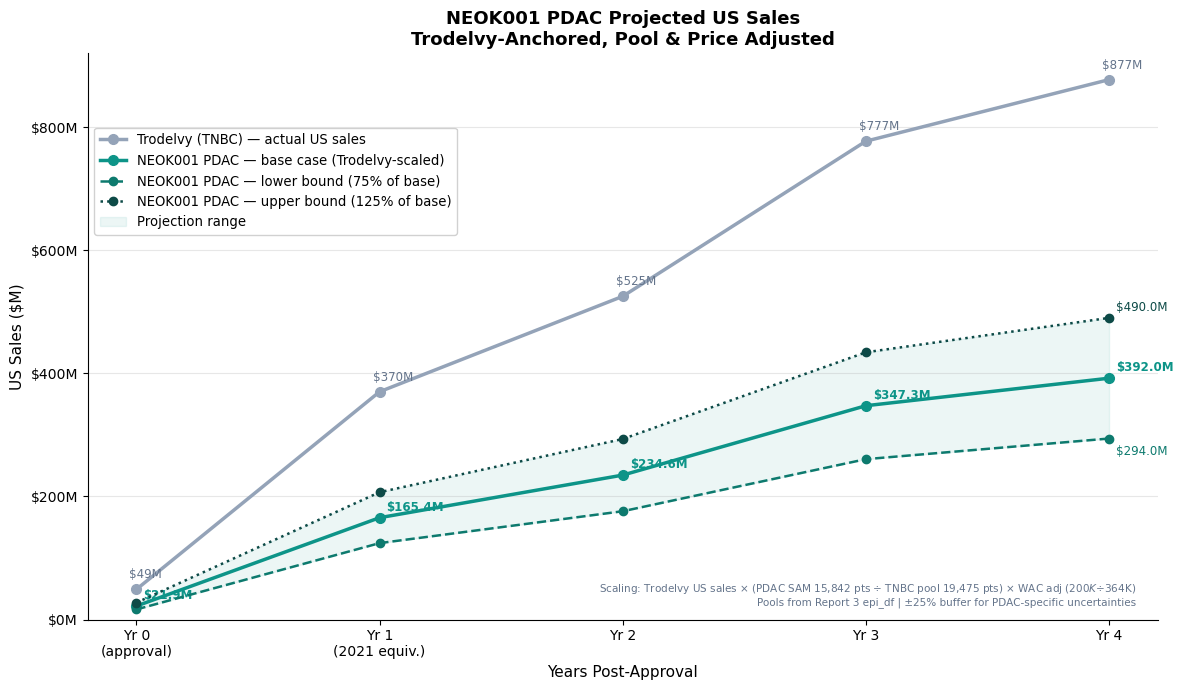

Saved to data/images/04_neok001_revenue_projection.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# ── BENCHMARK TRAJECTORY DATA ─────────────────────────────────
# Trodelvy US sales — Gilead Sciences financial reports
# Year 0 = partial approval year (April 2020)
# Year 1 = first full year (2021)
trodelvy_years = [0, 1, 2, 3, 4]
trodelvy_sales = [49, 370, 525, 777, 877]

# ── SCALING PARAMETERS ────────────────────────────────────────
TRODELVY_POOL = 19475   # TNBC addressable pool (Report 4 epi_df)
                         # 48,687 incidence × 40% eligible
TRODELVY_WAC  = 364     # Trodelvy annual WAC $K/yr
                         # $20,918/cycle × 17.4 cycles
NEOK_POOL     = 15842   # PDAC SAM
                         # 67,530 × 51% × 50% × 92%
NEOK_WAC      = 200     # NEOK001 assumed WAC $K/yr
                         # single Q3W infusion assumption
price_adj     = NEOK_WAC / TRODELVY_WAC  # 200/364 = 0.549

# ── NEOK001 PROJECTIONS ───────────────────────────────────────
neok_base = [
    round((s / TRODELVY_POOL) * NEOK_POOL * price_adj, 1)
    for s in trodelvy_sales
]
neok_conservative = [round(v * 0.75, 1) for v in neok_base]
neok_optimistic   = [round(v * 1.25, 1) for v in neok_base]

print("=== NEOK001 PROJECTED TRAJECTORIES ===\n")
print(f"Trodelvy pool: {TRODELVY_POOL:,} pts | "
      f"PDAC SAM: {NEOK_POOL:,} pts | "
      f"Price adj: {price_adj:.3f}\n")
print(f"{'Year':<6} {'Trodelvy':>10} {'Conservative':>14} "
      f"{'Base Case':>12} {'Optimistic':>12}")
print("-" * 58)
for yr, t, c, b, o in zip(trodelvy_years, trodelvy_sales,
                            neok_conservative, neok_base,
                            neok_optimistic):
    print(f"Yr {yr:<3} ${t:>8}M ${c:>12}M ${b:>10}M ${o:>10}M")

# ── PLOT ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Trodelvy actual
ax.plot(trodelvy_years, trodelvy_sales,
        color='#94A3B8', linewidth=2.5,
        marker='o', markersize=7,
        linestyle='-',
        label='Trodelvy (TNBC) — actual US sales',
        zorder=3)

# NEOK001 base case
ax.plot(trodelvy_years, neok_base,
        color=NEOK_TEAL, linewidth=2.5,
        marker='o', markersize=7,
        label='NEOK001 PDAC — base case (Trodelvy-scaled)',
        zorder=4)

# NEOK001 conservative
ax.plot(trodelvy_years, neok_conservative,
        color=NEOK_MID, linewidth=1.8,
        marker='o', markersize=6,
        linestyle='--',
        label='NEOK001 PDAC — lower bound (75% of base)',
        zorder=4)

# NEOK001 optimistic
ax.plot(trodelvy_years, neok_optimistic,
        color=NEOK_DARK, linewidth=1.8,
        marker='o', markersize=6,
        linestyle=':',
        label='NEOK001 PDAC — upper bound (125% of base)',
        zorder=4)

# shade projection range
ax.fill_between(trodelvy_years,
                neok_conservative, neok_optimistic,
                alpha=0.08, color=NEOK_TEAL,
                label='Projection range')

# annotate Trodelvy endpoints
for yr, val in zip(trodelvy_years, trodelvy_sales):
    ax.annotate(f'${val}M',
                xy=(yr, val),
                xytext=(-5, 8), textcoords='offset points',
                fontsize=8.5, color='#64748B')

# annotate NEOK001 base case endpoints
for yr, val in zip(trodelvy_years, neok_base):
    ax.annotate(f'${val}M',
                xy=(yr, val),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8.5, color=NEOK_TEAL,
                fontweight='bold')

# annotate bounds at year 4 only
ax.annotate(f'${neok_conservative[-1]}M',
            xy=(trodelvy_years[-1], neok_conservative[-1]),
            xytext=(5, -12), textcoords='offset points',
            fontsize=8.5, color=NEOK_MID)
ax.annotate(f'${neok_optimistic[-1]}M',
            xy=(trodelvy_years[-1], neok_optimistic[-1]),
            xytext=(5, 5), textcoords='offset points',
            fontsize=8.5, color=NEOK_DARK)

# methodology note — bottom right
ax.text(0.98, 0.02,
        f'Scaling: Trodelvy US sales × (PDAC SAM {NEOK_POOL:,} pts'
        f' ÷ TNBC pool {TRODELVY_POOL:,} pts) × WAC adj'
        f' (${NEOK_WAC}K ÷ ${TRODELVY_WAC}K)\n'
        f'Pools from Report 3 epi_df | ±25% buffer for PDAC-specific uncertainties',
        transform=ax.transAxes,
        fontsize=7.5, color='#64748B',
        verticalalignment='bottom',
        horizontalalignment='right')

ax.set_xlabel('Years Post-Approval', fontsize=11)
ax.set_ylabel('US Sales ($M)', fontsize=11)
ax.set_title('NEOK001 PDAC Projected US Sales\n'
             'Trodelvy-Anchored, Pool & Price Adjusted',
             fontsize=13, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xticklabels(['Yr 0\n(approval)', 'Yr 1\n(2021 equiv.)',
                    'Yr 2', 'Yr 3', 'Yr 4'])
ax.legend(fontsize=9.5, loc='upper left', framealpha=0.9,
          bbox_to_anchor=(0.0, 0.88))
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/04_neok001_revenue_projection.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/images/04_neok001_revenue_projection.png")